In [2]:
# cell 1:
import sys, os, json
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import joblib

from src.utils import load_config, set_seed
from src.cross_dataset.alignment import build_alignment_report, rename_2018_to_2017_schema
from src.preprocessing.cross_dataset_cleaning import clean_target_dataset, encode_target_labels
from src.evaluation.metrics import evaluate_model, print_metrics, results_to_dataframe

cfg = load_config()
set_seed(cfg["project"]["random_state"])

# --- Load 2018 raw data ---
path_2018 = os.path.join(cfg["paths"]["cicids2018_dir"], "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv")
df_2018_raw = pd.read_csv(path_2018, low_memory=False)
df_2018_raw.columns = [str(c).strip() for c in df_2018_raw.columns]

# --- Load selected features + build alignment ---
with open(os.path.join(cfg["paths"]["reports_dir"], "selected_features.json")) as f:
    selection_info = json.load(f)
selected_features_2017 = selection_info["selected_features"]

alignment_report = build_alignment_report(selected_features_2017)
X_2018_aligned = rename_2018_to_2017_schema(df_2018_raw, alignment_report)
y_2018_raw = df_2018_raw["Label"]

print("Aligned 2018 features:", X_2018_aligned.shape)

# --- Clean and encode ---
X_2018_clean, y_2018_clean_raw = clean_target_dataset(X_2018_aligned, y_2018_raw)
y_2018_binary = encode_target_labels(y_2018_clean_raw, benign_label="Benign")

print("\nFinal 2018 test set:", X_2018_clean.shape)
print("Binary label distribution:")
print(y_2018_binary.value_counts())
print(f"Class balance: {y_2018_binary.value_counts(normalize=True).round(4).to_dict()}")

Aligned 2018 features: (1048575, 20)
TARGET DATASET (2018) CLEANING REPORT
Rows at start:                1,048,575
Duplicate rows removed:       487,465
Infinite values found:        0
Rows removed (NaN/inf):       0
Final rows:                   561,110

Final 2018 test set: (561110, 20)
Binary label distribution:
_label_raw
0    360519
1    200591
Name: count, dtype: int64
Class balance: {0: 0.6425, 1: 0.3575}


In [3]:
#cell2:
models_dir = cfg["paths"]["models_dir"]
final_rf = joblib.load(os.path.join(models_dir, "final_model_random_forest.joblib"))

in_dataset_results = pd.read_csv(os.path.join(cfg["paths"]["metrics_dir"], "final_model_metrics.csv"))
print("In-dataset (2017) performance:")
print(in_dataset_results[["model", "accuracy", "f1", "roc_auc", "fpr", "fnr"]])

In-dataset (2017) performance:
                           model  accuracy        f1  roc_auc       fpr  \
0  Final RF (tuned, 20 features)   0.99991  0.999922      1.0  0.000105   

        fnr  
0  0.000078  


In [4]:
#cell3:
cross_metrics = evaluate_model(final_rf, X_2018_clean, y_2018_binary, model_name="Final RF - Cross-Dataset (2018)")
print_metrics(cross_metrics)

RESULTS: Final RF - Cross-Dataset (2018)
Accuracy   : 0.6425
Precision  : 0.0000
Recall     : 0.0000
F1-score   : 0.0000
ROC-AUC    : 0.6004
PR-AUC     : 0.4748
FPR        : 0.0000
FNR        : 1.0000
------------------------------------------------------------
Confusion Matrix:
              Predicted BENIGN   Predicted DDoS
Actual BENIGN       360,519                 0
Actual DDoS         200,591                 0
------------------------------------------------------------
Prediction time  : 3.1220 sec


In [5]:
#Add cell4:
import numpy as np

print("Fwd Packet Length Max - by class and dataset:\n")

print("2017 (training domain):")
X_train_selected_path = os.path.join(cfg["paths"]["processed_dir"], "X_train_selected.parquet")
y_train_path = os.path.join(cfg["paths"]["processed_dir"], "y_train.parquet")
X_train_selected = pd.read_parquet(X_train_selected_path)
y_train = pd.read_parquet(y_train_path)["label_binary"]

print(X_train_selected.groupby(y_train)["Fwd Packet Length Max"].describe()[["mean", "std", "min", "50%", "max"]])

print("\n2018 (target domain):")
print(X_2018_clean.groupby(y_2018_binary)["Fwd Packet Length Max"].describe()[["mean", "std", "min", "50%", "max"]])

Fwd Packet Length Max - by class and dataset:

2017 (training domain):
                     mean          std  min   50%      max
label_binary                                              
0             1259.101140  2714.276404  0.0  42.0  11680.0
1               14.897111     6.738057  6.0  20.0     20.0

2018 (target domain):
                  mean         std  min    50%     max
_label_raw                                            
0           930.116088   66.163847  0.0  935.0  2224.0
1           244.459098  118.522571  0.0  291.0   365.0


In [6]:
#Cell 5 — run the domain shift analysis (BENIGN class, since it's most comparable across domains):
from src.cross_dataset.domain_shift import compute_domain_shift_report, print_domain_shift_summary

# Compare BENIGN traffic distributions (most fair comparison - both are
# "normal" traffic, so any shift here reflects environment/capture
# differences rather than different attack tools)
X_2017_benign = X_train_selected.loc[y_train == 0]
X_2018_benign = X_2018_clean.loc[y_2018_binary == 0]

shift_report_benign = compute_domain_shift_report(X_2017_benign, X_2018_benign)
print_domain_shift_summary(shift_report_benign)

shift_report_benign.to_csv(os.path.join(cfg["paths"]["reports_dir"], "domain_shift_benign.csv"), index=False)

DOMAIN SHIFT SUMMARY
Features tested:                20
Features with significant shift (KS p<0.05): 20/20
----------------------------------------------------------------
Top 10 most shifted features (by KS statistic):
                    feature  ks_statistic  wasserstein_normalized  significant_shift
    Init_Win_bytes_backward      0.984300                4.801120               True
     Init_Win_bytes_forward      0.980699                5.314916               True
      Bwd Packet Length Max      0.850506                0.562209               True
      Fwd Packet Length Max      0.785858                0.608449               True
     Fwd Packet Length Mean      0.776668                0.600863               True
Total Length of Fwd Packets      0.736974                0.523206               True
              Bwd Packets/s      0.729450                0.131120               True
          Total Fwd Packets      0.702151                0.218402               True
     Packet Len

In [7]:
#Cell 6 — same for DDoS class (the more important one for your discussion):
X_2017_ddos = X_train_selected.loc[y_train == 1]
X_2018_ddos = X_2018_clean.loc[y_2018_binary == 1]

shift_report_ddos = compute_domain_shift_report(X_2017_ddos, X_2018_ddos)
print_domain_shift_summary(shift_report_ddos)

shift_report_ddos.to_csv(os.path.join(cfg["paths"]["reports_dir"], "domain_shift_ddos.csv"), index=False)

DOMAIN SHIFT SUMMARY
Features tested:                20
Features with significant shift (KS p<0.05): 17/20
----------------------------------------------------------------
Top 10 most shifted features (by KS statistic):
                    feature  ks_statistic  wasserstein_normalized  significant_shift
     Init_Win_bytes_forward      0.991375               13.684494               True
           act_data_pkt_fwd      0.979560              650.377386               True
               Flow IAT Std      0.937027                0.632716               True
      Fwd Packet Length Max      0.824962               34.381360               True
     Fwd Packet Length Mean      0.824962               61.728682               True
Total Length of Fwd Packets      0.824952             2724.256158               True
              Bwd Packets/s      0.737248                0.173128               True
    Init_Win_bytes_backward      0.636445                0.415156               True
     Packet Len

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\domain_shift_top_feature.png


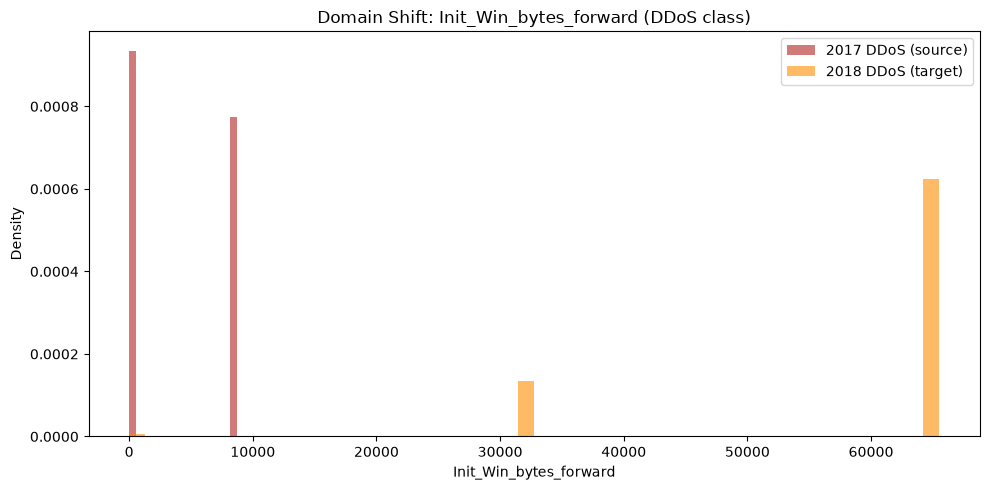

In [8]:
#Cell 7 — visualize the top-shifted feature's distribution side by side:
import matplotlib.pyplot as plt

top_feature = shift_report_ddos.iloc[0]["feature"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(X_2017_ddos[top_feature], bins=50, alpha=0.6, label="2017 DDoS (source)", density=True, color="firebrick")
ax.hist(X_2018_ddos[top_feature], bins=50, alpha=0.6, label="2018 DDoS (target)", density=True, color="darkorange")
ax.set_title(f"Domain Shift: {top_feature} (DDoS class)")
ax.set_xlabel(top_feature)
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()

from src.utils import save_figure
save_figure(fig, "domain_shift_top_feature.png", cfg)
plt.show()

In [9]:
import json

cross_dataset_summary_path = os.path.join(cfg["paths"]["reports_dir"], "cross_dataset_all_results.json")

with open(cross_dataset_summary_path) as f:
    all_cross_results = json.load(f)

all_cross_results["cse_cic_ids2018"] = {
    "dataset_name": "CSE-CIC-IDS2018 (Wed-21-02, HOIC+LOIC-UDP)",
    "feature_overlap": "20/20 (100%)",
    "same_tool": True,
    "tool_used": "CICFlowMeter (newer version)",
    "n_samples": int(len(y_2018_binary)),
    "accuracy": float(cross_metrics["accuracy"]),
    "precision": float(cross_metrics["precision"]),
    "recall": float(cross_metrics["recall"]),
    "f1": float(cross_metrics["f1"]),
    "roc_auc": float(cross_metrics["roc_auc"]),
    "pr_auc": float(cross_metrics["pr_auc"]),
    "fpr": float(cross_metrics["fpr"]),
    "fnr": float(cross_metrics["fnr"]),
    "tn": int(cross_metrics["tn"]),
    "fp": int(cross_metrics["fp"]),
    "fn": int(cross_metrics["fn"]),
    "tp": int(cross_metrics["tp"]),
    "notes": "Root cause quantified via KS-test domain shift analysis - packet-length features (top model dependency) among most-shifted",
}

with open(cross_dataset_summary_path, "w") as f:
    json.dump(all_cross_results, f, indent=2)

print("Saved 2018 results. Combined file now contains:", list(all_cross_results.keys()))

Saved 2018 results. Combined file now contains: ['unsw_nb15', 'cicddos2019', 'cse_cic_ids2018']


In [10]:
X_2018_clean.to_parquet(os.path.join(cfg["paths"]["processed_dir"], "cross_dataset_2018_X.parquet"))
y_2018_binary.to_frame(name="label_binary").to_parquet(os.path.join(cfg["paths"]["processed_dir"], "cross_dataset_2018_y.parquet"))
print("Saved 2018 cross-dataset X/y for live demo use.")

Saved 2018 cross-dataset X/y for live demo use.
